# Realized Volatility Timing and Dynamic Carry Allocation

## Abstract

This notebook studies whether a model-based estimate of realized volatility can improve the execution of short-volatility carry strategies. The latent variance process is modeled with a Heston state-space specification and estimated with an Unscented Kalman Filter (UKF). The resulting model-based volatility estimate is compared with a simpler historical benchmark based on 21-day realized volatility and a static allocation.

The notebook is designed as a **self-contained report**: it recomputes all experiments directly from the raw market data. The workflow is deliberately organized in three layers:

1. a short sample used to explain the methodology and inspect the mechanics of the signal,
2. a full-sample SPY study,
3. a full-sample AAPL robustness check.

The central research question is the following: does the implied-realized spread,

$$
 s_t = \sigma^{IV}_t - \widehat{\sigma}_t,
$$

provide useful information for dynamically scaling a short-volatility carry strategy ?


## 1. Reproducibility, Scope, and Runtime

A few practical remarks are important:

- the notebook recomputes the short sample, the SPY full sample, and the AAPL full sample inside the notebook itself;
- full-sample runs are materially slower than the short sample because each signal requires repeated rolling calibrations of the Heston model;
- on a typical machine, a long run can take on the order of **tens of minutes**. In practice this made exhaustive grid-search calibration of the dynamic allocation rule difficult.

In [1]:
import logging
import sys
from datetime import datetime
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'realized_vol_timing').exists() and (PROJECT_ROOT.parent / 'realized_vol_timing').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from investment_lab.backtest import StrategyBacktester
from realized_vol_timing import (
    AllocationConfig,
    DynamicAllocationPolicy,
    HestonUKFConfig,
    RollingWindowConfig,
    TradeAllocator,
    compute_proxy_metrics,
    resolve_experiment_dates,
    run_carry_experiment,
    summarize_backtests,
)

logging.getLogger().setLevel(logging.ERROR)

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)
plt.style.use('seaborn-v0_8-whitegrid')

RUN_SHORT_SAMPLE = True
RUN_SPY_FULL_SAMPLE = True
RUN_AAPL_FULL_SAMPLE = True

SHORT_SAMPLE_TICKER = 'SPY'
SHORT_SAMPLE_START = datetime(2020, 1, 2)
SHORT_SAMPLE_END = datetime(2020, 9, 30)
SPY_FULL_START, SPY_FULL_END = resolve_experiment_dates('SPY', full_sample=True)
AAPL_FULL_START, AAPL_FULL_END = resolve_experiment_dates('AAPL', full_sample=True)

ukf_config = HestonUKFConfig(optimizer_maxiter=12)
rolling_config = RollingWindowConfig(window=42, refit_every=10)
allocation_config = AllocationConfig(
    zscore_window=21,
    base_allocation=1.0,
    sensitivity=0.4,
    min_allocation=0.0,
    max_allocation=2.0,
    zscore_clip=3.0,
    ewm_span=5,
)

allocation_variants = {
    'Conservative': AllocationConfig(
        zscore_window=21,
        base_allocation=0.75,
        sensitivity=0.25,
        min_allocation=0.0,
        max_allocation=1.25,
        zscore_clip=3.0,
        ewm_span=5,
    ),
    'Baseline': allocation_config,
    'Aggressive': AllocationConfig(
        zscore_window=21,
        base_allocation=1.0,
        sensitivity=0.8,
        min_allocation=0.0,
        max_allocation=4.0,
        zscore_clip=3.0,
        ewm_span=3,
    ),
}

sample_table = pd.DataFrame(
    [
        {'experiment': 'Short explanatory sample', 'ticker': SHORT_SAMPLE_TICKER, 'start_date': SHORT_SAMPLE_START.date(), 'end_date': SHORT_SAMPLE_END.date()},
        {'experiment': 'SPY full sample', 'ticker': 'SPY', 'start_date': SPY_FULL_START.date(), 'end_date': SPY_FULL_END.date()},
        {'experiment': 'AAPL full sample', 'ticker': 'AAPL', 'start_date': AAPL_FULL_START.date(), 'end_date': AAPL_FULL_END.date()},
    ]
)

config_table = pd.DataFrame(
    {
        'parameter': [
            'UKF optimizer_maxiter',
            'rolling window',
            'refit_every',
            'allocation zscore_window',
            'allocation EWMA span',
            'base_allocation',
            'sensitivity',
            'min_allocation',
            'max_allocation',
        ],
        'value': [
            ukf_config.optimizer_maxiter,
            rolling_config.window,
            rolling_config.refit_every,
            allocation_config.zscore_window,
            allocation_config.ewm_span,
            allocation_config.base_allocation,
            allocation_config.sensitivity,
            allocation_config.min_allocation,
            allocation_config.max_allocation,
        ],
    }
)

display(sample_table)
display(config_table)


,experiment,ticker,start_date,end_date
0,Short explanatory sample,SPY,2020-01-02,2020-09-30
1,SPY full sample,SPY,2020-01-02,2022-12-30
2,AAPL full sample,AAPL,2016-01-04,2023-03-31


,parameter,value
0,UKF optimizer_maxiter,12.0
1,rolling window,42.0
2,refit_every,10.0
3,allocation zscore_window,21.0
4,allocation EWMA span,5.0
5,base_allocation,1.0
6,sensitivity,0.4
7,min_allocation,0.0
8,max_allocation,2.0


## 2. Data and Sample Design

The empirical analysis uses the option datasets available locally in the project. In practice the pipeline works with daily option-chain information and extracts from it:

- the underlying spot level,
- daily log-returns,
- an ATM implied volatility proxy,
- the option legs used to backtest the carry strategy.

Two assets are studied:

- **SPY**, used as the main reference asset because it is the most natural underlier for a volatility carry study;
- **AAPL**, used as a robustness check on a more idiosyncratic equity name.

The short sample is not meant to replace the full-sample study. It is used because it makes the mechanics of the method easier to visualize and debug before moving to the more expensive runs.


## 3. Heston State-Space Model and UKF Estimation

The latent variance dynamics follow the Heston specification:

$$
\begin{aligned}
 dS_t &= \mu S_t\,dt + S_t\sqrt{v_t}\,dW_t^{(1)}, \\
 dv_t &= \kappa(\theta - v_t)\,dt + \xi\sqrt{v_t}\,dW_t^{(2)}, \\
 d\langle W^{(1)}, W^{(2)}\rangle_t &= \rho\,dt.
\end{aligned}
$$

Here:

- $S_t$ is the observed underlying price,
- $v_t$ is the latent instantaneous variance,
- $\mu$ is the drift,
- $\kappa$ is the speed of mean reversion,
- $\theta$ is the long-run variance level,
- $\xi$ is the volatility of variance,
- $\rho$ captures the instantaneous correlation between spot and variance shocks.

Working with daily log-returns,

$$
 r_{t+1} = \log\left(\frac{S_{t+1}}{S_t}\right),
$$

a first-order discretization leads to the state-space system

$$
\begin{aligned}
 v_{t+1} &\approx v_t + \kappa(\theta - v_t)\Delta t + \xi\sqrt{v_t\Delta t}\,\varepsilon^v_{t+1}, \\
 r_{t+1} &\approx \left(\mu - \tfrac{1}{2}v_t\right)\Delta t + \sqrt{v_t\Delta t}\,\varepsilon^S_{t+1}, \\
 \text{Corr}(\varepsilon^S_{t+1}, \varepsilon^v_{t+1}) &= \rho.
\end{aligned}
$$

The key point is that $v_t$ is not observed directly. The UKF is used to estimate this latent state while preserving the nonlinear structure of the model without linearizing it as aggressively as a standard Kalman filter would.


## 4. Rolling Calibration, Realized Volatility Benchmarks, and Signal Construction

### 4.1 Rolling maximum-likelihood calibration

The Heston parameters are re-estimated on a rolling window. Denoting the parameter vector by

$$
\Theta = (\mu, \kappa, \theta, \xi, \rho, v_0),
$$

the rolling estimator at time $t$ is obtained from

$$
\widehat{\Theta}_t
=
\arg\max_{\Theta}
\sum_{u=t-W+1}^{t}
\log p(r_u \mid r_{t-W+1:u-1}; \Theta),
$$

where the likelihood is evaluated through the UKF. In the present implementation, the rolling window is set to $W=42$ business days and the optimization is refreshed every 10 observations.

### 4.2 Implied volatility proxy

The implied-volatility input is extracted from the option data as a simple ATM proxy: the code selects the option closest to ATM on the call side and on the put side, around a target maturity of 30 calendar days, and averages the two implied volatilities.

This choice is simple and robust, but it is also a limitation of the current notebook: no full volatility surface is calibrated here.

### 4.3 Historical realized-volatility benchmark

A model-free benchmark is constructed from rolling historical returns. For a 21-day window,

$$
RV^{21}_t = \sqrt{252}\;\mathrm{Std}(r_{t-20}, \ldots, r_t).
$$

The same construction is also reported with 63 business days as a slower benchmark. In the codebase, `RV_21d` and `RV_63d` are therefore annualized rolling standard deviations of daily log-returns.

### 4.4 Spread definitions

The main signal studied in the notebook is the implied-realized spread:

$$
s_t^{UKF} = \sigma^{IV}_t - \widehat{\sigma}^{UKF}_t,
$$

where

$$
\widehat{\sigma}^{UKF}_t = \sqrt{\widehat{v}_t}.
$$

A benchmark spread is also computed:

$$
s_t^{RV} = \sigma^{IV}_t - RV^{21}_t.
$$

This benchmark matters because it tells us whether a sophisticated latent-state model actually dominates a much simpler historical proxy.


## 5. Dynamic Allocation Rule

The carry strategy used in the backtest is a short 1-week strangle. The signal does **not** change the sign of the strategy: it only scales the size of the short-volatility position.

The allocation rule is implemented in four steps.

### Step 1. Smooth the spread

$$
\widetilde{s}_t = \mathrm{EWMA}_5(s_t).
$$

The EWMA span is intentionally short. It is not meant to impose a long-memory forecast; it simply reduces day-to-day noise before standardization.

### Step 2. Standardize the smoothed spread

$$
 z_t = \frac{\widetilde{s}_t - \overline{\widetilde{s}}_{t,21}}{\mathrm{Std}_{t,21}(\widetilde{s})}.
$$

### Step 3. Clip the z-score

$$
 z_t^{clip} = \min(3, \max(-3, z_t)).
$$

### Step 4. Convert the signal into an allocation multiplier

The standardized signal is converted into a time-varying allocation rule according to

$$
a_t = \mathrm{clip}(a_0 + \lambda z_t^{clip}, a_{min}, a_{max}),
$$

where:

- $a_t$ is the allocation multiplier applied to the baseline carry strategy at date $t$;
- $a_0$ is the baseline allocation, that is, the exposure used when the signal is neutral;
- $\lambda$ controls the sensitivity of the allocation to the signal;
- $z_t^{clip}$ is the clipped z-score of the spread, which measures how favorable or unfavorable the spread is relative to its recent history;
- $a_{min}$ is the minimum allowed allocation;
- $a_{max}$ is the maximum allowed allocation.

With the baseline specification,

$$
a_0 = 1.0,
\quad \lambda = 0.4,
\quad a_{min} = 0,
\quad a_{max} = 2,
$$

the interpretation is the following:

- when the signal is close to zero, the strategy remains close to its baseline exposure;
- when the signal is positive, the allocation increases above 1, meaning that the short-volatility carry position is reinforced;
- when the signal is negative, the allocation decreases below 1, meaning that the strategy scales down its exposure;
- because $a_{min}=0$, the strategy can fully switch off the carry trade, but it never becomes long volatility;
- because $a_{max}=2$, the leverage of the timed strategy remains capped at twice the baseline exposure.


Interpretation:

- if implied volatility is high relative to estimated realized volatility, the spread is positive and the allocation is increased;
- if the spread is weak or negative, the exposure is reduced;
- because $a_{min}=0$, the notebook never turns the strategy into a long-volatility trade. The signal only moves the portfolio between **flat** and **more or less short volatility** (because the goal is to study carry strategy).


In [2]:
def run_experiment_bundle(
    ticker: str,
    start_date: datetime,
    end_date: datetime,
    label: str,
):
    start_clock = perf_counter()
    experiment = run_carry_experiment(
        ticker=ticker,
        start_date=start_date,
        end_date=end_date,
        ukf_config=ukf_config,
        rolling_config=rolling_config,
        allocation_config=allocation_config,
    )
    runtime_seconds = perf_counter() - start_clock
    proxy_metrics = compute_proxy_metrics(experiment.signal_frame)

    nav_frame = (
        experiment.base_backtest.nav.rename(columns={'NAV': 'base_nav'})
        .join(experiment.ukf_timed_backtest.nav.rename(columns={'NAV': 'ukf_timed_nav'}), how='outer')
        .join(experiment.rv_timed_backtest.nav.rename(columns={'NAV': 'rv_21d_timed_nav'}), how='outer')
        .reset_index()
        .rename(columns={'index': 'date'})
    )
    nav_frame['date'] = pd.to_datetime(nav_frame['date'])

    signal_ukf = experiment.signal_frame.copy().sort_values('date').reset_index(drop=True)
    signal_rv = experiment.rv_signal_frame.copy().sort_values('date').reset_index(drop=True)
    parameters = experiment.parameter_frame.copy().sort_values('date').reset_index(drop=True)

    warmup_summary = pd.DataFrame(
        {
            'requested_start_date': [pd.Timestamp(start_date)],
            'requested_end_date': [pd.Timestamp(end_date)],
            'first_rv_21d_date': [signal_rv['date'].min() if not signal_rv.empty else pd.NaT],
            'first_ukf_signal_date': [signal_ukf['date'].min() if not signal_ukf.empty else pd.NaT],
        }
    )
    warmup_summary['days_until_rv_21d'] = (
        warmup_summary['first_rv_21d_date'] - warmup_summary['requested_start_date']
    ).dt.days
    warmup_summary['days_until_ukf_signal'] = (
        warmup_summary['first_ukf_signal_date'] - warmup_summary['requested_start_date']
    ).dt.days

    return {
        'label': label,
        'ticker': ticker,
        'requested_start_date': pd.Timestamp(start_date),
        'requested_end_date': pd.Timestamp(end_date),
        'runtime_seconds': runtime_seconds,
        'experiment': experiment,
        'signal_ukf': signal_ukf,
        'signal_rv': signal_rv,
        'parameters': parameters,
        'comparison': experiment.comparison_frame.copy(),
        'proxy_metrics': proxy_metrics.copy(),
        'nav': nav_frame.copy(),
        'warmup_summary': warmup_summary,
    }


def merge_signal_views(bundle: dict) -> pd.DataFrame:
    signal_ukf = bundle['signal_ukf'].copy()
    signal_rv = bundle['signal_rv'].copy()
    merged = signal_ukf.merge(
        signal_rv[['date', 'ticker', 'benchmark_realized_vol', 'spread', 'allocation']].rename(
            columns={
                'benchmark_realized_vol': 'rv_21d_benchmark',
                'spread': 'spread_rv_21d',
                'allocation': 'allocation_rv_21d',
            }
        ),
        on=['date', 'ticker'],
        how='left',
    )
    merged['date'] = pd.to_datetime(merged['date'])
    return merged.sort_values('date').reset_index(drop=True)


def display_headline_tables(bundle: dict) -> None:
    runtime_minutes = bundle['runtime_seconds'] / 60.0
    print(f"{bundle['label']} | runtime = {runtime_minutes:.2f} minutes")
    display(bundle['comparison'])
    display(bundle['proxy_metrics'])
    display(bundle['warmup_summary'])


def plot_signal_overview(bundle: dict) -> None:
    signal = merge_signal_views(bundle)
    nav = bundle['nav'].sort_values('date')
    requested_start = bundle['requested_start_date']
    first_ukf_date = signal['date'].min() if not signal.empty else None

    fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

    axes[0].plot(signal['date'], signal['atm_implied_vol'], label='ATM IV proxy', color='steelblue')
    axes[0].plot(signal['date'], signal['estimated_realized_vol'], label='UKF volatility estimate', color='crimson', linestyle='--')
    axes[0].plot(signal['date'], signal['rv_21d'], label='RV 21d', color='darkgreen')
    axes[0].plot(signal['date'], signal['rv_63d'], label='RV 63d', color='purple', alpha=0.75)
    axes[0].set_title(f"{bundle['label']} - volatility proxies")
    axes[0].set_ylabel('Volatility')
    axes[0].legend(loc='upper left')

    axes[1].plot(signal['date'], signal['spread'], label='IV - UKF', color='darkorange')
    axes[1].plot(signal['date'], signal['spread_rv_21d'], label='IV - RV 21d', color='teal', alpha=0.9)
    axes[1].axhline(0.0, color='black', linewidth=0.8)
    axes[1].set_title('Implied-realized spreads')
    axes[1].set_ylabel('Spread')
    axes[1].legend(loc='upper left')

    axes[2].plot(signal['date'], signal['allocation'], label='Allocation from UKF spread', color='darkorange')
    axes[2].plot(signal['date'], signal['allocation_rv_21d'], label='Allocation from RV 21d spread', color='teal', alpha=0.9)
    axes[2].axhline(1.0, color='black', linestyle=':', linewidth=0.8)
    axes[2].set_title('Dynamic allocation multipliers')
    axes[2].set_ylabel('Allocation')
    axes[2].legend(loc='upper left')

    axes[3].plot(nav['date'], nav['base_nav'], label='Base carry')
    axes[3].plot(nav['date'], nav['ukf_timed_nav'], label='Timed carry using UKF')
    axes[3].plot(nav['date'], nav['rv_21d_timed_nav'], label='Timed carry using RV 21d')
    axes[3].set_title('NAV comparison')
    axes[3].set_ylabel('NAV')
    axes[3].set_xlabel('Date')
    axes[3].legend(loc='upper left')

    if first_ukf_date is not None and requested_start < first_ukf_date:
        for ax in axes:
            ax.axvspan(requested_start, first_ukf_date, color='grey', alpha=0.12)
        axes[0].text(
            requested_start,
            axes[0].get_ylim()[1] * 0.97,
            'Warm-up period',
            fontsize=9,
            color='dimgray',
            va='top',
        )

    fig.tight_layout()
    plt.show()


def plot_heston_parameters(bundle: dict) -> None:
    parameters = bundle['parameters'].copy()
    fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
    parameter_names = ['kappa', 'theta', 'xi', 'rho', 'mu', 'v0']
    for ax, name in zip(axes.flat, parameter_names):
        ax.plot(parameters['date'], parameters[name], linewidth=1.1)
        ax.set_title(name)
    fig.suptitle(f"{bundle['label']} - rolling Heston parameters", y=1.02)
    fig.tight_layout()
    plt.show()


def build_runtime_table(*bundles: dict | None) -> pd.DataFrame:
    rows = []
    for bundle in bundles:
        if bundle is None:
            continue
        rows.append(
            {
                'experiment': bundle['label'],
                'ticker': bundle['ticker'],
                'requested_start': bundle['requested_start_date'].date(),
                'requested_end': bundle['requested_end_date'].date(),
                'runtime_minutes': round(bundle['runtime_seconds'] / 60.0, 2),
            }
        )
    return pd.DataFrame(rows)


## 6. Experimental Protocol

The notebook compares three strategies on each sample:

1. **Base carry**: the short 1-week strangle is traded with constant unit allocation.
2. **Timed carry using UKF**: the same base trades are multiplied by the dynamic allocation derived from the Heston-UKF spread.
3. **Timed carry using RV 21d**: the same base trades are multiplied by the dynamic allocation derived from the historical-volatility benchmark spread.

The evaluation relies on four standard metrics:

- total return,
- Sharpe ratio,
- Calmar ratio,
- maximum drawdown.

This design is intentionally conservative: the comparison isolates the effect of the volatility-timing signal without changing the option strategy itself.


100%|██████████| 194/194 [00:00<00:00, 260.77it/s]

Short sample | runtime = 0.61 minutes


,total_return,sharpe_ratio,calmar_ratio,max_drawdown
strategy,,,,
Base carry,0.005274,0.162163,0.271776,-0.029652
Timed carry UKF,0.006053,0.167459,0.316955,-0.029652
Timed carry RV_21d,0.014045,0.527744,1.057052,-0.017732


,corr_vs_rv_21d,corr_vs_rv_63d,mae_vs_rv_21d,mae_vs_rv_63d
proxy,,,,
UKF sigma_hat,0.218992,0.387890,0.323784,0.304847
IV ATM,0.860743,0.649157,0.099676,0.149424


,requested_start_date,requested_end_date,first_rv_21d_date,first_ukf_signal_date,days_until_rv_21d,days_until_ukf_signal
0,2020-01-02,2020-09-30,2020-02-03,2020-03-04,32,62


,date,atm_implied_vol,estimated_realized_vol,rv_21d,rv_63d,spread,allocation
134,2020-09-15,0.204180,0.347535,0.211120,0.175615,-0.143355,0.607540
135,2020-09-16,0.207575,0.363581,0.211350,0.172384,-0.156006,0.753467
136,2020-09-17,0.213395,0.487461,0.213556,0.173278,-0.274066,0.683763
137,2020-09-18,0.211465,0.480865,0.219394,0.174950,-0.269400,0.657025
138,2020-09-21,0.235325,1.253209,0.221466,0.176198,-1.017884,0.000000
139,2020-09-22,0.222695,0.720521,0.224290,0.176954,-0.497826,0.075948
140,2020-09-23,0.248395,0.470731,0.233128,0.175968,-0.222336,0.436213
141,2020-09-24,0.246135,0.501272,0.232846,0.174971,-0.255137,0.629503
142,2020-09-25,0.218080,0.507217,0.237956,0.170099,-0.289137,0.726696
143,2020-09-28,0.222360,0.443678,0.246970,0.170797,-0.221318,0.865218


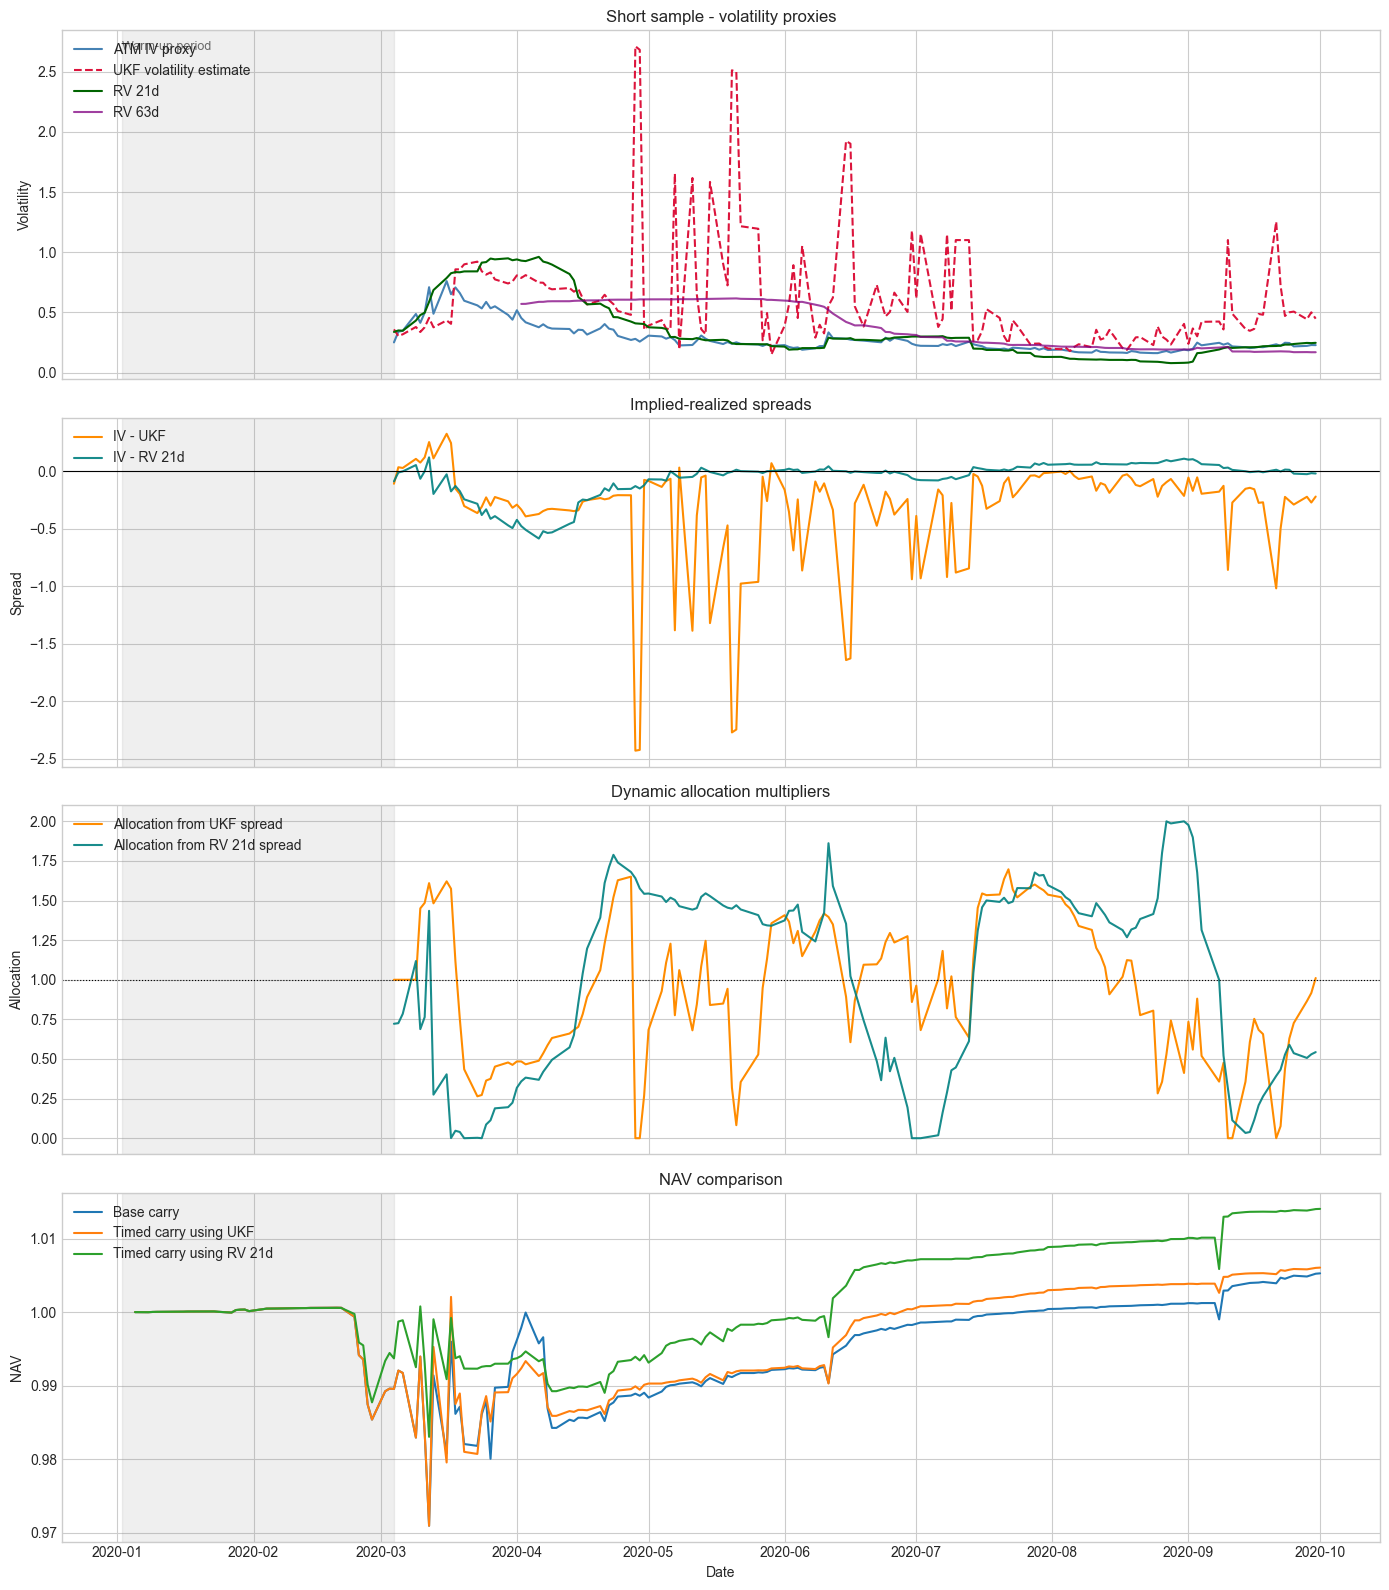

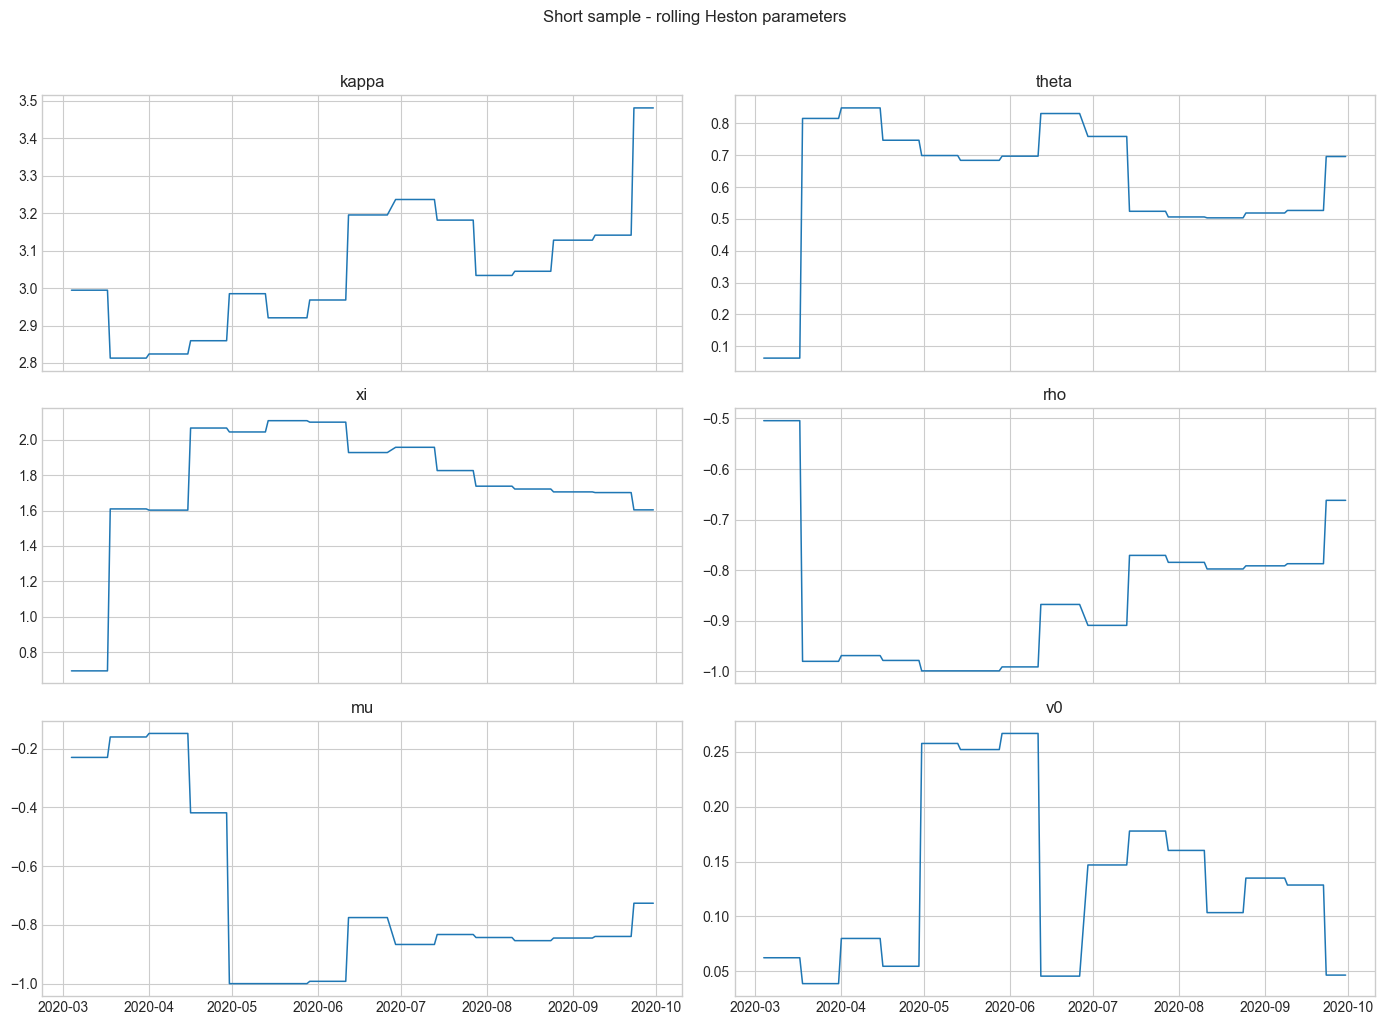

In [3]:
short_sample_bundle = None
if RUN_SHORT_SAMPLE:
    short_sample_bundle = run_experiment_bundle(
        SHORT_SAMPLE_TICKER,
        SHORT_SAMPLE_START,
        SHORT_SAMPLE_END,
        label='Short sample',
    )
    display_headline_tables(short_sample_bundle)
    display(
        short_sample_bundle['signal_ukf'][[
            'date', 'atm_implied_vol', 'estimated_realized_vol', 'rv_21d', 'rv_63d', 'spread', 'allocation'
        ]].tail(12)
    )
    plot_signal_overview(short_sample_bundle)
    plot_heston_parameters(short_sample_bundle)


## 7. Short-Sample Reading: Why the Graphs Do Not Start on the First Day

- `RV_21d` only becomes available after roughly 21 business days of data;
- the UKF-based signal only becomes available once the first rolling calibration window is complete;
- the allocation based on the UKF spread can therefore only start once the UKF signal exists.

In the present configuration, this warm-up effect is substantial because the Heston rolling calibration uses a 42-business-day window. The shaded region at the start of the plots corresponds to this initialization period.

In [4]:
if short_sample_bundle is not None:
    short_signal = short_sample_bundle['signal_ukf'].copy().dropna(subset=['spread'])
    allocation_diagnostics = short_signal[['date', 'spread', 'smoothed_spread', 'spread_zscore', 'allocation']].copy()
    display(allocation_diagnostics.tail(12))
    display(allocation_diagnostics['allocation'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_frame('allocation'))


,date,spread,smoothed_spread,spread_zscore,allocation
134,2020-09-15,-0.143355,-0.234351,-0.981151,0.607540
135,2020-09-16,-0.156006,-0.208236,-0.616332,0.753467
136,2020-09-17,-0.274066,-0.230179,-0.790593,0.683763
137,2020-09-18,-0.269400,-0.243253,-0.857437,0.657025
138,2020-09-21,-1.017884,-0.501463,-2.859484,0.000000
139,2020-09-22,-0.497826,-0.500251,-2.310130,0.075948
140,2020-09-23,-0.222336,-0.407613,-1.409468,0.436213
141,2020-09-24,-0.255137,-0.356787,-0.926243,0.629503
142,2020-09-25,-0.289137,-0.334237,-0.683259,0.726696
143,2020-09-28,-0.221318,-0.296597,-0.336954,0.865218


,allocation
count,146.000000
mean,0.938488
std,0.441112
min,0.000000
10%,0.356964
25%,0.613030
50%,0.954644
75%,1.307439
90%,1.535525
max,1.697243


## 8. Allocation Sensitivity Analysis on the Short Sample

The allocation rule contains discretionary choices. The purpose of this section is not to claim that one specification is globally optimal, but to understand how the strategy reacts when the risk budget is changed.

Three variants are considered:

- a **conservative** rule,
- the **baseline** rule used in the rest of the notebook,
- an **aggressive** rule with a higher ceiling (`max_allocation = 4.0`) and a faster EWMA.


100%|██████████| 194/194 [00:00<00:00, 283.89it/s]


,zscore_window,base_allocation,sensitivity,min_allocation,max_allocation,zscore_clip,ewm_span
Conservative,21,0.75,0.25,0.0,1.25,3.0,5
Baseline,21,1.00,0.40,0.0,2.00,3.0,5
Aggressive,21,1.00,0.80,0.0,4.00,3.0,3


,total_return,sharpe_ratio,calmar_ratio,max_drawdown
strategy,,,,
Conservative,0.002428,0.096328,0.165003,-0.024295
Baseline,0.006053,0.167459,0.316955,-0.029652
Aggressive,0.006279,0.158752,0.342407,-0.029652


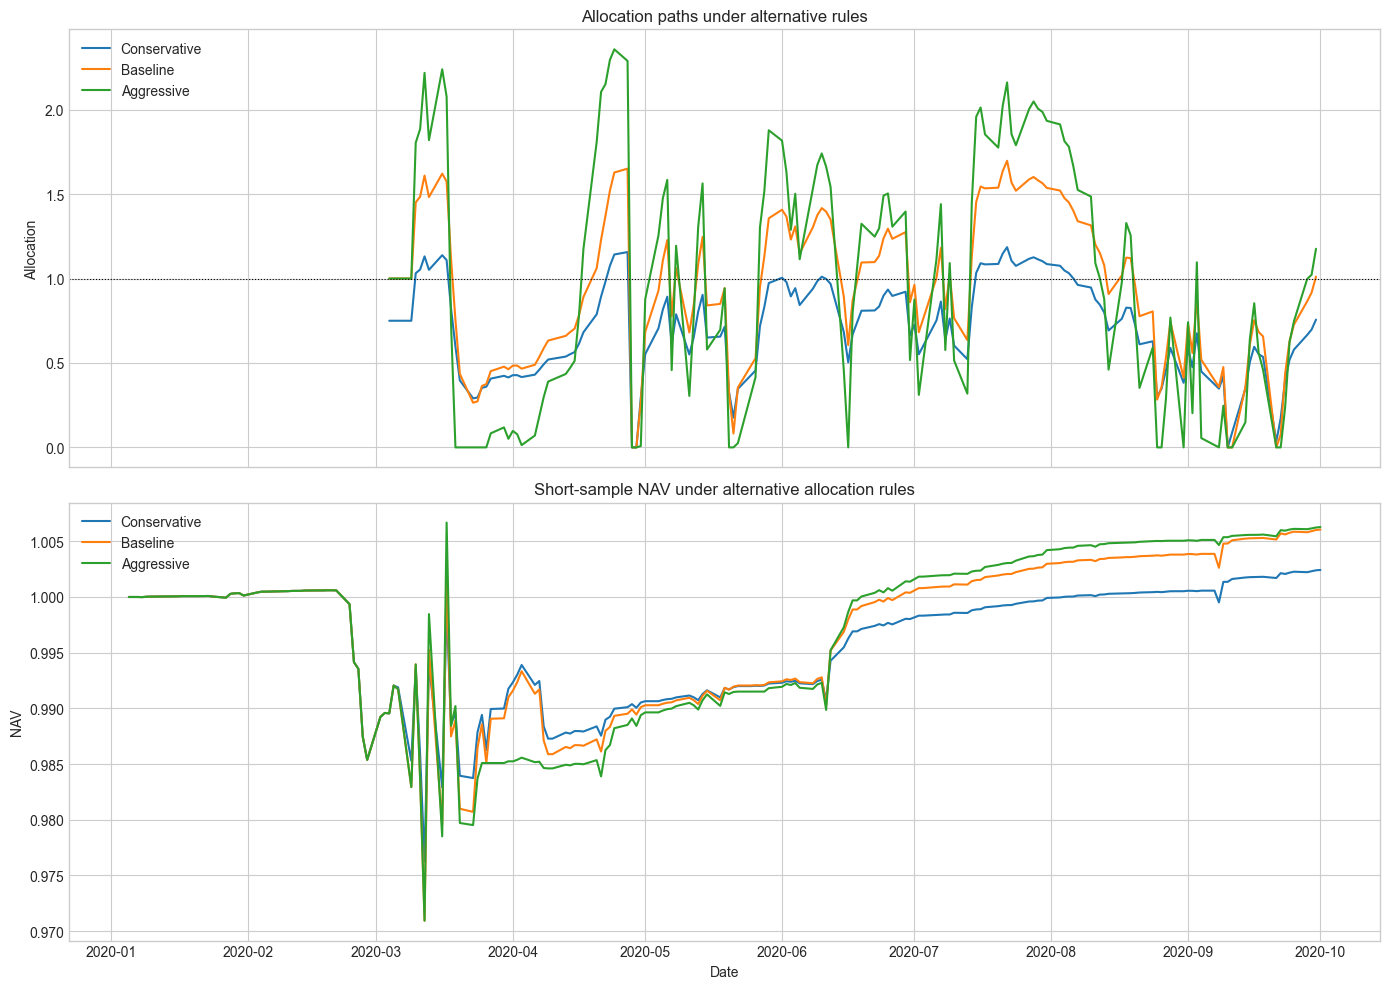

In [5]:
allocation_variant_results = None
if short_sample_bundle is not None:
    short_signal = short_sample_bundle['signal_ukf'].copy().dropna(subset=['spread'])
    trade_allocator = TradeAllocator()
    variant_signal_frames = {}
    variant_backtests = {}

    for name, config in allocation_variants.items():
        allocation_frame = DynamicAllocationPolicy(config).transform(short_signal['spread'])
        variant_signal = short_signal[['date', 'ticker', 'spread']].copy()
        variant_signal['allocation'] = allocation_frame['allocation'].to_numpy()
        variant_signal_frames[name] = variant_signal

        variant_trades = trade_allocator.apply(short_sample_bundle['experiment'].base_trades.copy(), variant_signal)
        variant_backtests[name] = StrategyBacktester(variant_trades).compute_backtest()

    allocation_variant_results = summarize_backtests(variant_backtests)
    display(pd.DataFrame([cfg.__dict__ for cfg in allocation_variants.values()], index=allocation_variants.keys()))
    display(allocation_variant_results)

    fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    for name, variant_signal in variant_signal_frames.items():
        axes[0].plot(variant_signal['date'], variant_signal['allocation'], label=name)
    axes[0].axhline(1.0, color='black', linestyle=':', linewidth=0.8)
    axes[0].set_title('Allocation paths under alternative rules')
    axes[0].set_ylabel('Allocation')
    axes[0].legend(loc='upper left')

    for name, backtest in variant_backtests.items():
        axes[1].plot(backtest.nav.index, backtest.nav['NAV'], label=name)
    axes[1].set_title('Short-sample NAV under alternative allocation rules')
    axes[1].set_ylabel('NAV')
    axes[1].set_xlabel('Date')
    axes[1].legend(loc='upper left')

    fig.tight_layout()
    plt.show()


### Discussion of the Allocation Experiment

Two points are worth emphasizing.

First, the allocation rule matters. The same spread can lead to very different realized trajectories once sensitivity, smoothing, and leverage caps are changed.

Second, this is exactly where computational cost becomes relevant. Because the full notebook already requires expensive rolling Heston calibrations, an exhaustive grid-search over many allocation rules becomes operationally cumbersome. This is why the notebook explores a small number of interpretable scenarios rather than a large brute-force hyperparameter search.

The limited difference between the aggressive and baseline specifications is itself informative. It suggests that, over this sample, the signal is useful but not extreme: most of the time, the spread remains in a range where all three rules recommend exposures that are relatively close to the baseline allocation. In other words, the main source of value comes from adjusting the carry exposure in the right direction, not from taking substantially more leverage.

## 9. Full-Sample SPY Study

100%|██████████| 781/781 [00:02<00:00, 280.76it/s]


SPY full sample | runtime = 1.42 minutes


,total_return,sharpe_ratio,calmar_ratio,max_drawdown
strategy,,,,
Base carry,0.038134,0.485716,0.418207,-0.029652
Timed carry UKF,0.048988,0.548707,0.534434,-0.029652
Timed carry RV_21d,0.051989,0.855387,0.932798,-0.017732


,corr_vs_rv_21d,corr_vs_rv_63d,mae_vs_rv_21d,mae_vs_rv_63d
proxy,,,,
UKF sigma_hat,0.461482,0.611983,0.105983,0.097897
IV ATM,0.851540,0.663562,0.048803,0.054122


,requested_start_date,requested_end_date,first_rv_21d_date,first_ukf_signal_date,days_until_rv_21d,days_until_ukf_signal
0,2020-01-02,2022-12-30,2020-02-03,2020-03-04,32,62


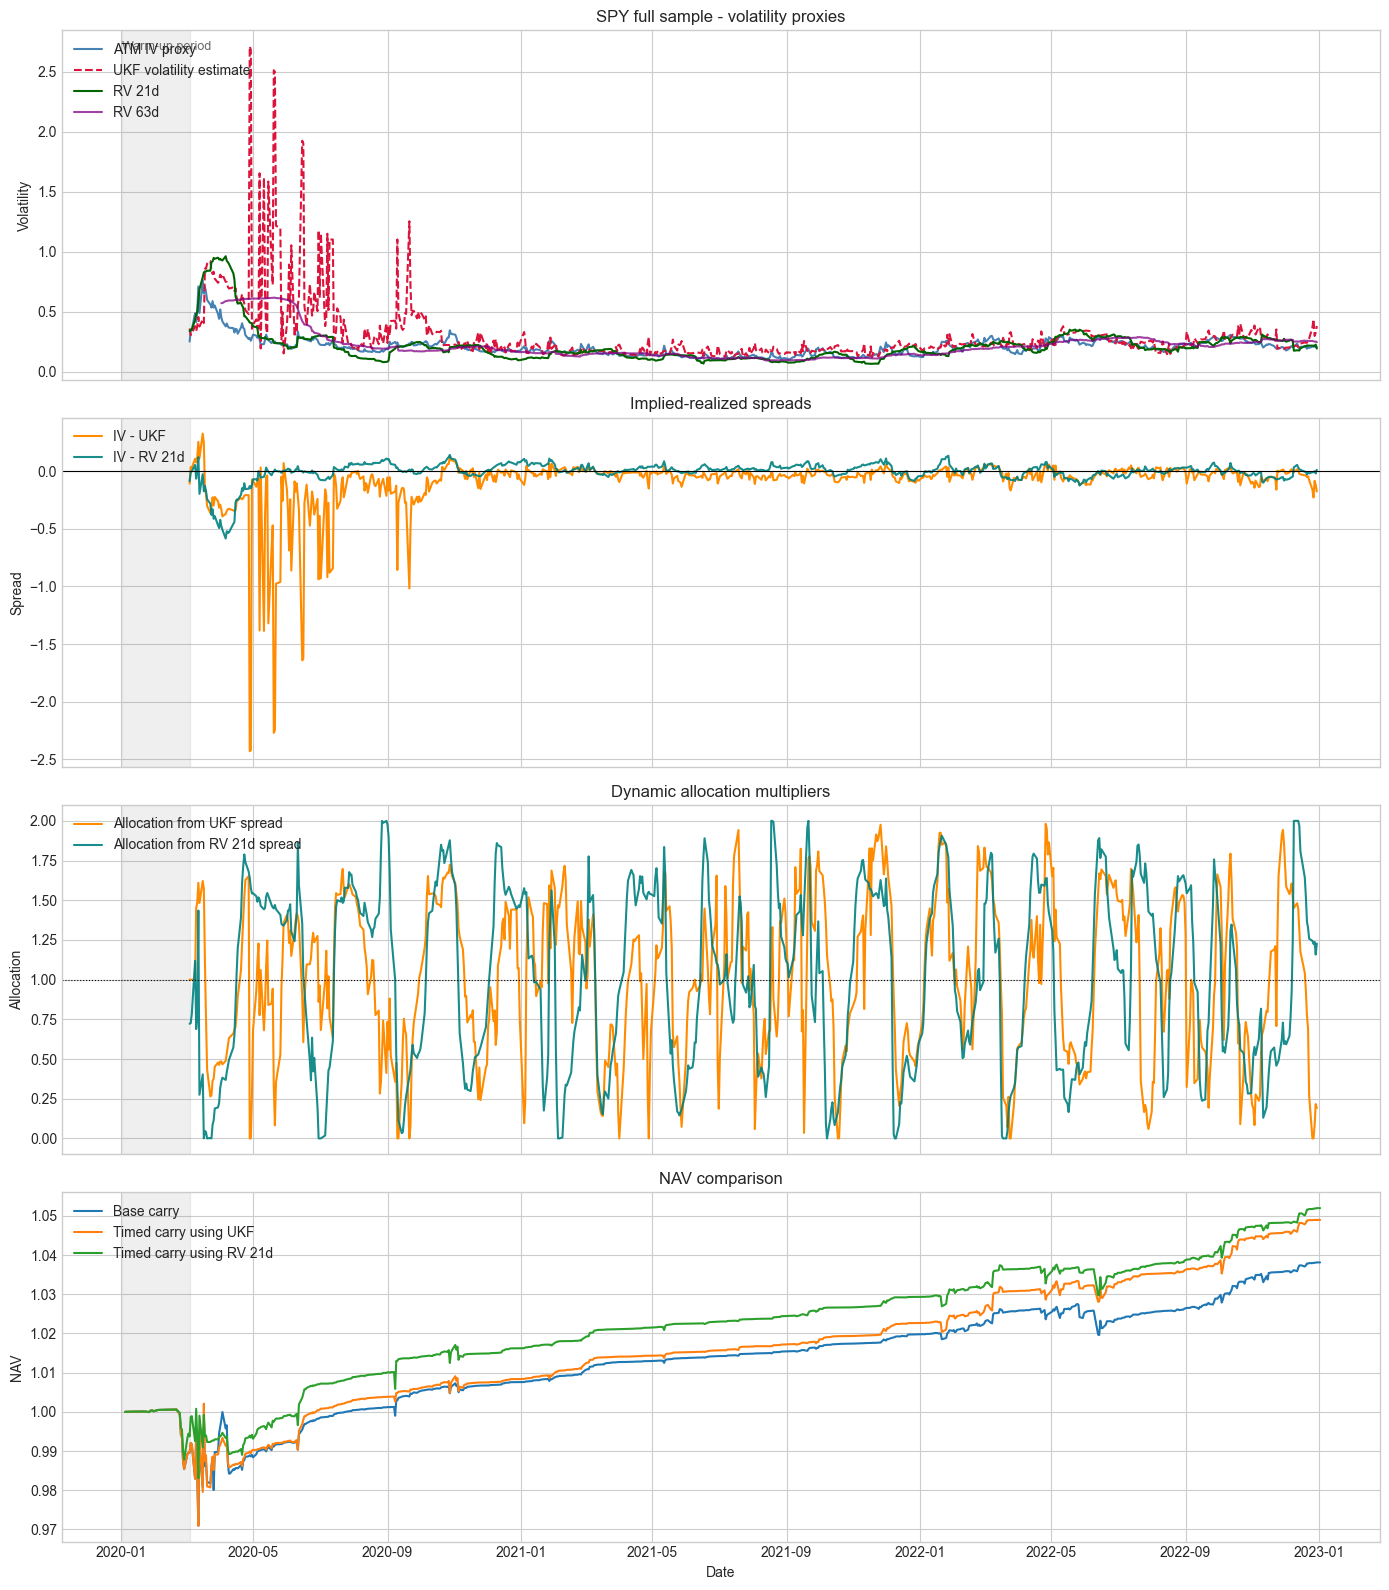

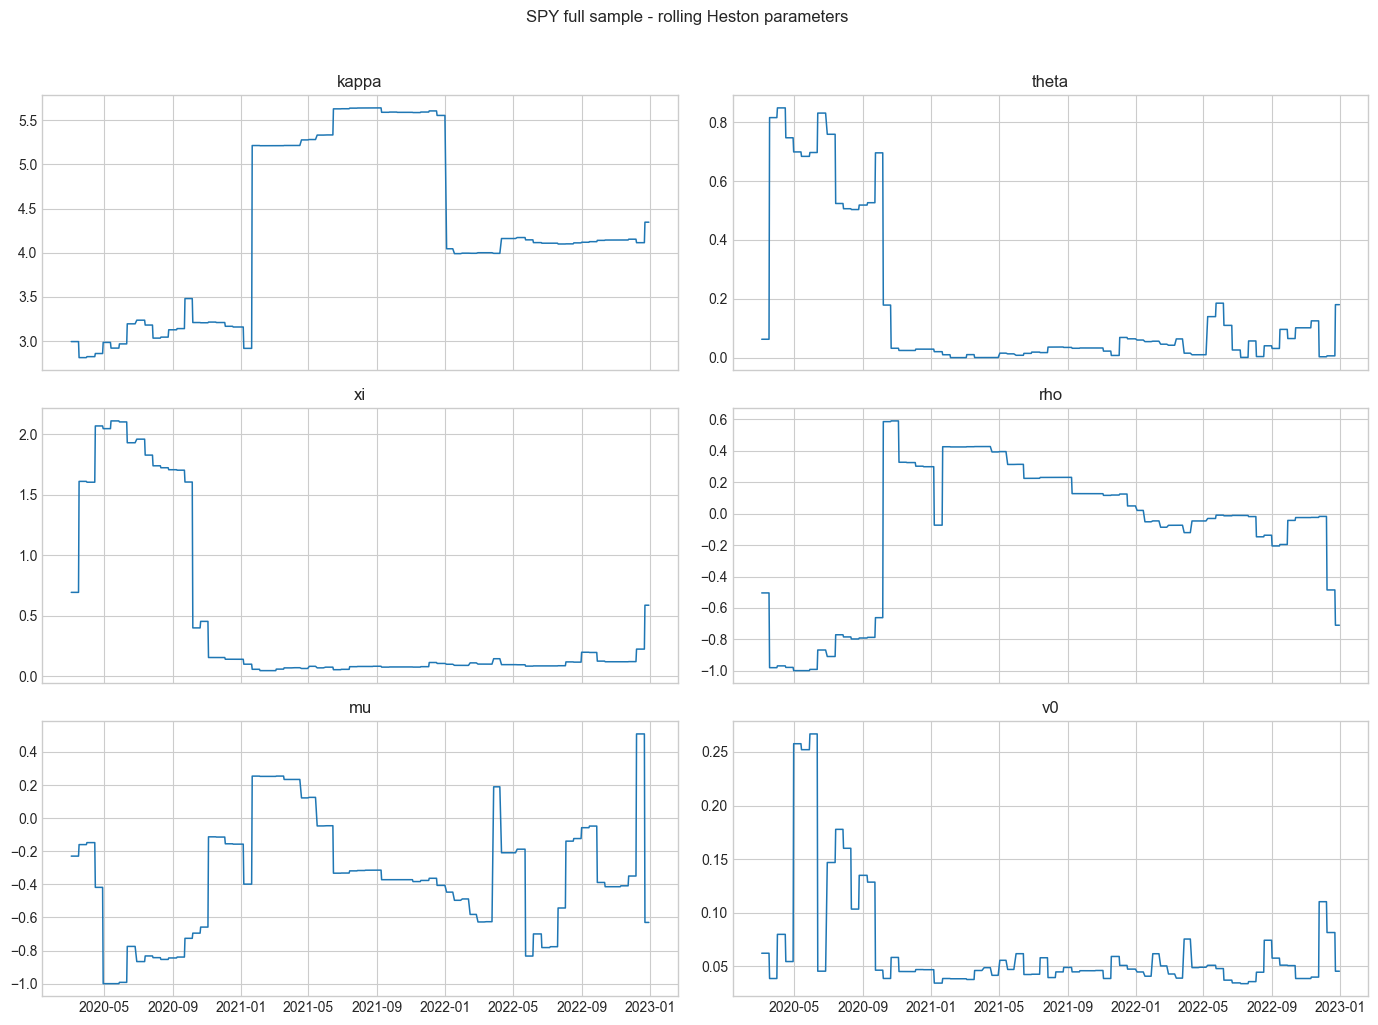

In [6]:
spy_full_bundle = None
if RUN_SPY_FULL_SAMPLE:
    spy_full_bundle = run_experiment_bundle(
        'SPY',
        SPY_FULL_START,
        SPY_FULL_END,
        label='SPY full sample',
    )
    display_headline_tables(spy_full_bundle)
    plot_signal_overview(spy_full_bundle)
    plot_heston_parameters(spy_full_bundle)


### Interpretation of the SPY Full-Sample Results

- Relative to **base carry**, a useful timing model should improve either absolute return, risk-adjusted return, or drawdown control.
- Relative to **RV 21d timing**, a useful latent-state model should demonstrate that the added modeling complexity is not purely cosmetic.

On this sample, both timing rules improve on the static carry benchmark. The base carry strategy delivers a total return of **3.81%**, with a Sharpe ratio of **0.49** and a maximum drawdown of **-2.97%**. The UKF-based timing increases the total return to **4.90%** and the Sharpe ratio to **0.55**, while keeping the same drawdown.

However, the simpler `RV_21d` timing rule remains very competitive and, in the present calibration, stronger on SPY. It reaches a total return of **5.20%**, a Sharpe ratio of **0.86**, and a smaller maximum drawdown of **-1.77%**. In other words, the timing idea works, but the latent-state model does not yet dominate a simpler realized-volatility benchmark.

The proxy comparison reinforces this conclusion. The UKF-estimated volatility is positively related to realized volatility, with correlations of **0.46** against `RV_21d` and **0.61** against `RV_63d`, so it clearly captures part of the volatility dynamics. Yet the ATM implied volatility is more strongly aligned with the realized-volatility benchmarks, with a correlation of **0.85** versus `RV_21d`, and it also exhibits lower MAE. This suggests that, on SPY, market-implied volatility already contains a large amount of useful information.

Overall, this is an important empirical result: the Heston-UKF framework is directionally useful and improves upon base carry, but the added modeling complexity is not yet clearly superior to a simpler historical-volatility timing rule. This does not invalidate the state-space approach; rather, it shows that it should be judged against strong empirical baselines, not only against an untimed carry strategy.


## 10. Full-Sample AAPL Robustness Check

AAPL is used as a cross-sectional robustness test. Unlike SPY, it is not an index ETF and therefore carries more idiosyncratic single-name risk. If the timing logic survives this change in underlier, the signal is more convincing.


100%|██████████| 1890/1890 [00:06<00:00, 286.35it/s]


AAPL full sample | runtime = 2.53 minutes


,total_return,sharpe_ratio,calmar_ratio,max_drawdown
strategy,,,,
Base carry,0.186557,0.624300,0.512204,-0.045915
Timed carry UKF,0.212504,0.592012,0.419203,-0.063714
Timed carry RV_21d,0.289876,0.976562,0.743387,-0.046502


,corr_vs_rv_21d,corr_vs_rv_63d,mae_vs_rv_21d,mae_vs_rv_63d
proxy,,,,
UKF sigma_hat,0.339506,0.555854,0.200790,0.181118
IV ATM,0.457480,0.462195,0.116031,0.137137


,requested_start_date,requested_end_date,first_rv_21d_date,first_ukf_signal_date,days_until_rv_21d,days_until_ukf_signal
0,2016-01-04,2023-03-31,2016-02-03,2016-03-04,30,60


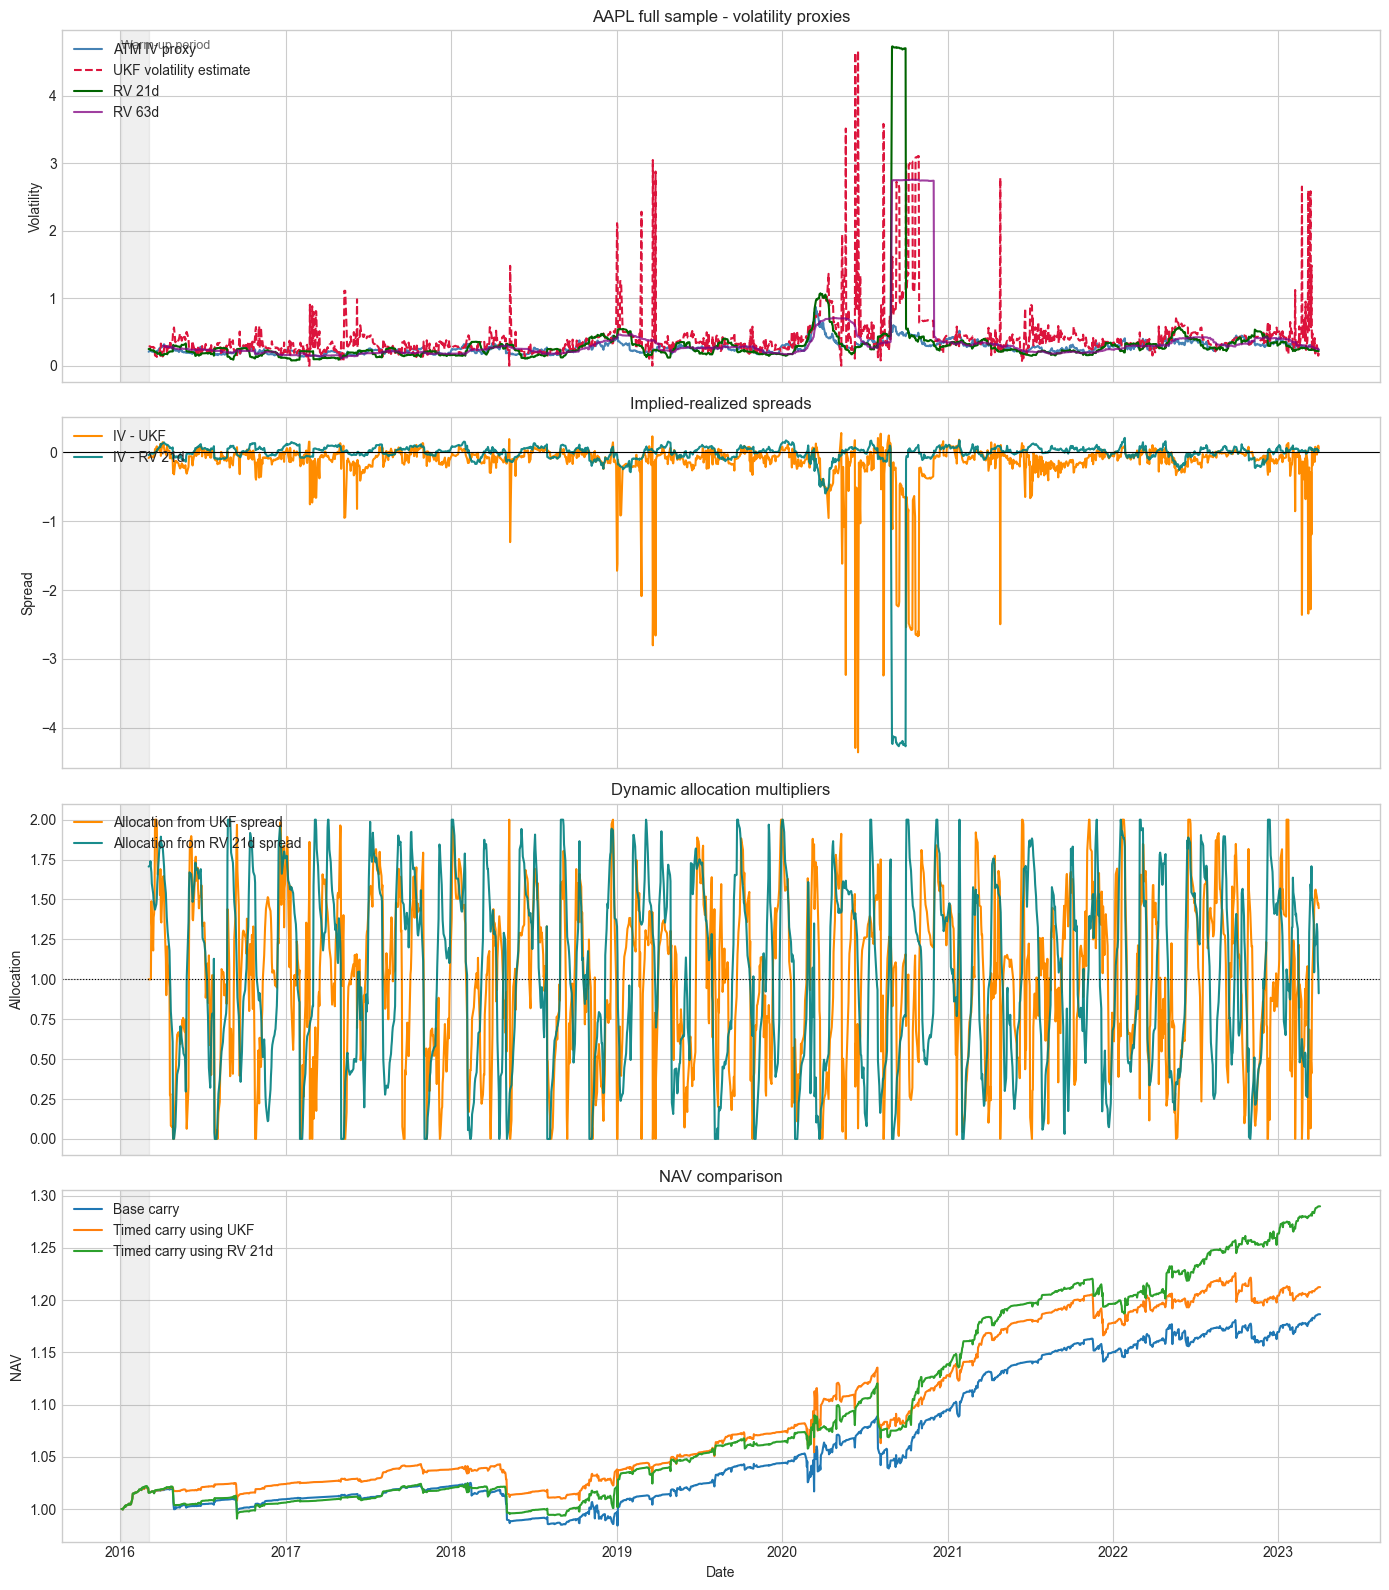

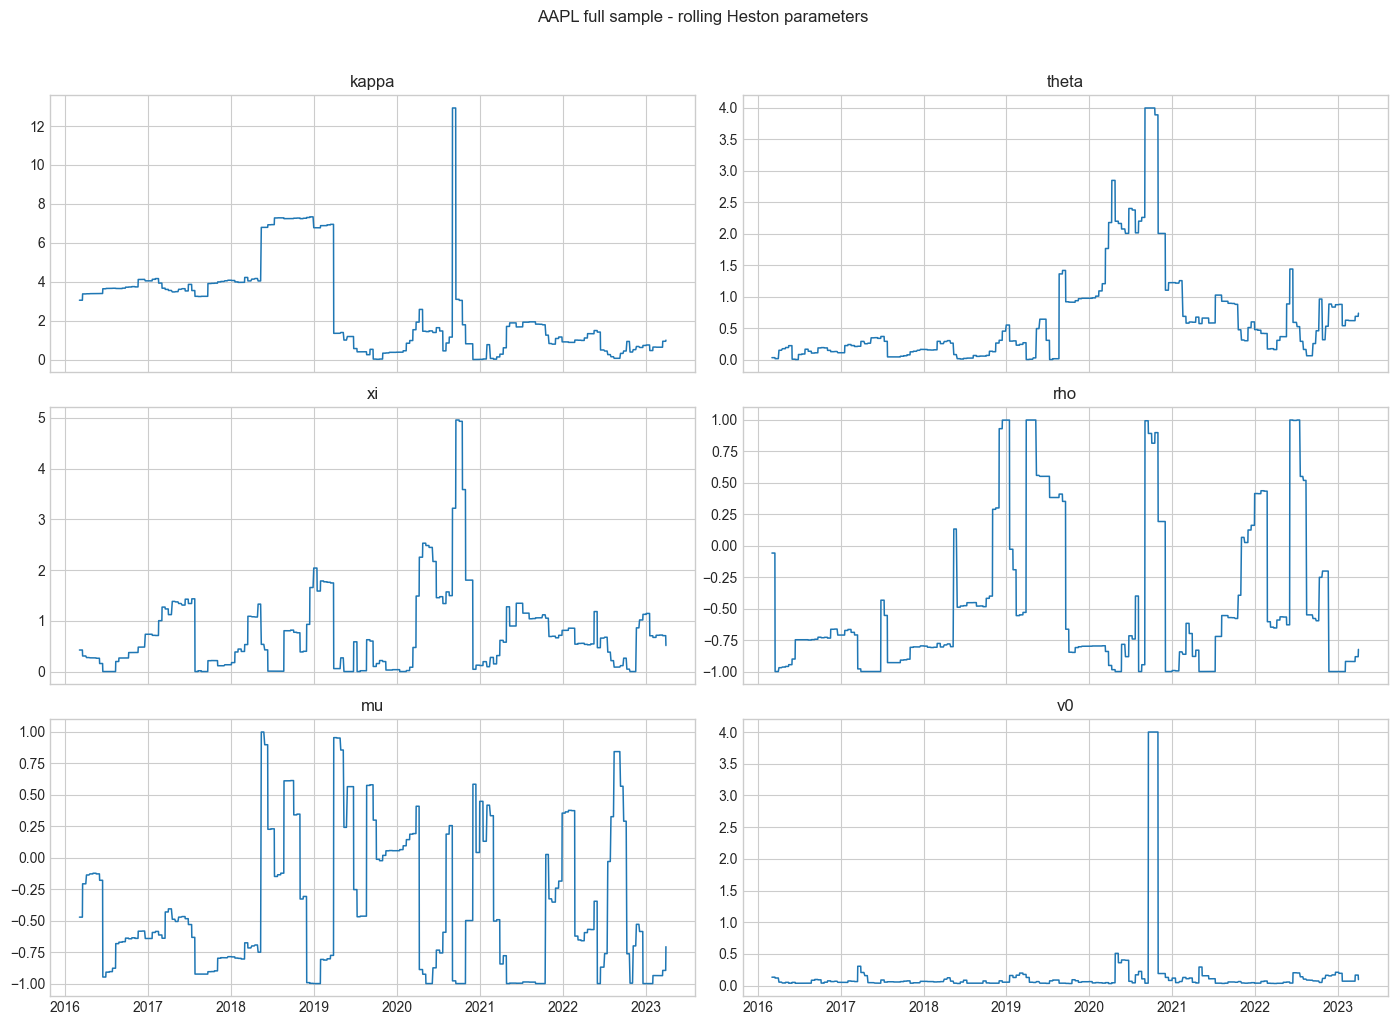

In [7]:
aapl_full_bundle = None
if RUN_AAPL_FULL_SAMPLE:
    aapl_full_bundle = run_experiment_bundle(
        'AAPL',
        AAPL_FULL_START,
        AAPL_FULL_END,
        label='AAPL full sample',
    )
    display_headline_tables(aapl_full_bundle)
    plot_signal_overview(aapl_full_bundle)
    plot_heston_parameters(aapl_full_bundle)


### Interpretation of the AAPL Full-Sample Results

On AAPL, the main conclusion is similar but more pronounced. Both timing rules improve on the base carry strategy, and the `RV_21d` timing rule is again the strongest specification in the current implementation.

The base carry strategy delivers a total return of **18.66%**, with a Sharpe ratio of **0.62** and a maximum drawdown of **-4.59%**. The UKF-timed strategy improves total return to **21.25%**, but with a slightly lower Sharpe ratio (**0.59**) and a larger drawdown (**-6.37%**). By contrast, the `RV_21d` timing rule achieves **28.99%** total return, a Sharpe ratio of **0.98**, and a drawdown close to the base strategy (**-4.65%**).

The proxy comparison also remains mixed for the UKF. Its estimated volatility is positively correlated with realized-volatility benchmarks, but less strongly than ATM implied volatility on `RV_21d`, and with materially larger MAE. Overall, the AAPL results confirm that volatility timing is economically valuable, but they also suggest that the current UKF calibration is not yet strong enough to outperform a simpler realized-volatility benchmark.


In [8]:
runtime_table = build_runtime_table(short_sample_bundle, spy_full_bundle, aapl_full_bundle)
display(runtime_table)

final_summary_rows = []
for bundle in [short_sample_bundle, spy_full_bundle, aapl_full_bundle]:
    if bundle is None:
        continue
    comparison = bundle['comparison'].copy().reset_index().rename(columns={'strategy': 'strategy_name'})
    comparison['experiment'] = bundle['label']
    final_summary_rows.append(comparison)

if final_summary_rows:
    final_summary = pd.concat(final_summary_rows, ignore_index=True)
    display(final_summary)


,experiment,ticker,requested_start,requested_end,runtime_minutes
0,Short sample,SPY,2020-01-02,2020-09-30,0.61
1,SPY full sample,SPY,2020-01-02,2022-12-30,1.42
2,AAPL full sample,AAPL,2016-01-04,2023-03-31,2.53


,strategy_name,total_return,sharpe_ratio,calmar_ratio,max_drawdown,experiment
0,Base carry,0.005274,0.162163,0.271776,-0.029652,Short sample
1,Timed carry UKF,0.006053,0.167459,0.316955,-0.029652,Short sample
2,Timed carry RV_21d,0.014045,0.527744,1.057052,-0.017732,Short sample
3,Base carry,0.038134,0.485716,0.418207,-0.029652,SPY full sample
4,Timed carry UKF,0.048988,0.548707,0.534434,-0.029652,SPY full sample
5,Timed carry RV_21d,0.051989,0.855387,0.932798,-0.017732,SPY full sample
6,Base carry,0.186557,0.624300,0.512204,-0.045915,AAPL full sample
7,Timed carry UKF,0.212504,0.592012,0.419203,-0.063714,AAPL full sample
8,Timed carry RV_21d,0.289876,0.976562,0.743387,-0.046502,AAPL full sample


## 11. Main Limitations and Difficulties Encountered

The notebook is fully operational, but several limitations should be stated explicitly.

### 11.1 ATM implied-volatility proxy

The implied-volatility input is built from a simple ATM proxy extracted from the data. This is robust and easy to reproduce, but it is not as rich as a full surface-based construction. A natural extension would be to replace the ATM proxy by either:

- a volatility built from the actual traded option legs,
- or a volatility surface estimate (for example SSVI / SABR) and then extract the relevant implied volatilities from that surface.

### 11.2 Computational cost

The long-sample runs are expensive because the Heston parameters are estimated repeatedly on rolling windows. In practice, the runtime of a long sample is on the order of many minutes, and on some machines can approach **30 minutes**. This makes broad hyperparameter searches costly and was one of the main practical obstacles of the project.

### 11.3 Benchmark strength

The 21-day realized-volatility benchmark is very competitive. A simple historical-volatility proxy is often surprisingly hard to beat.

### 11.4 No sign reversal

The current allocation rule only scales the size of the short-volatility trade. It can reduce the position to zero, but it does not turn the strategy into a long-volatility allocation. This keeps the design aligned with a carry interpretation, but it is also a modeling choice.
